# Binary Association

Through this guide, we will demonstrate the core features of `affinis`, and though this 
synthetic datastet has no underlying "structure" to recover, you will hopefully see how the various methods compare to each other. 

First, some setup of the python environment, for reproducibility: 

In [36]:
import numpy as np
import networkx as nx
import seaborn as sns
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path
plt.rc('figure', figsize=(4.0, 3.0))
sns.set_theme(style='white')
imgpath=Path('../../docs/user-guide/img/')


We are going to generate a random bipartite graph, as a stand-in for a binary feature matrix. 
This can represent a document-term matrix, user-preference (recommender) data, or any number of similar feature matrices. 

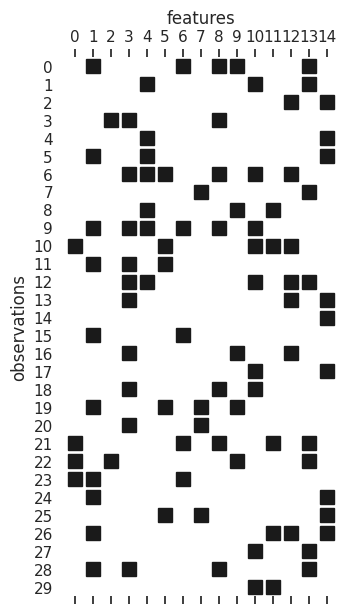

In [37]:
n_cols=15
n_rows=30
B = nx.bipartite.random_graph(n_cols,n_rows, .25, seed=2)
n = list(B.nodes)[n_cols:]

X = nx.bipartite.biadjacency_matrix(B, n).toarray()
plt.figure(figsize=(4,7))
plt.spy(X, marker='s', color='k')
ax = plt.gca()
sns.despine(left=True, bottom=True)
ax.xaxis.set_label_position('top') 
ax.set(
    xticks=range(n_cols), xticklabels=range(n_cols),
    yticks=range(n_rows), yticklabels=range(n_rows),
    xlabel="features", ylabel="observations"
);
plt.savefig(imgpath/'Xmat.webp')

Each row is an "observation", while each column is a feature that can be active or inactive, _during_ that observation. 


![feature matrix](img/Xmat.webp){ align=right }

From here, we will group the methods by the kinds of assumptions made, roughly corresponding to the taxonomy presented in [Sexton (2025)](https://dissertation.rtbs.dev/content/part1/1-03-recovery-road.html#tbl-roads): 



## Marginal Counts & Probabilities

This class of association measures cares less about any kind of underlying "structure" between features and more about _how_ observations are able to be counted/combined for statistical aggregation. 

The majority rely on the observational units being _additive_, such that we can apply an inner product $X^TX$ on them. 
Intuitively, such an inner product returns the co-occurrence counts of each feature, along with the overall count for a feature in the diagonal. 



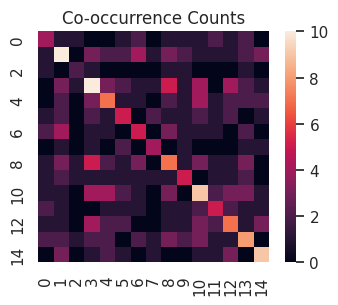

In [58]:
cooc = X.T@X
sns.heatmap(cooc, square=True)
plt.title('Co-occurrence Counts')
plt.savefig('../../docs/user-guide/img/cooc.webp')

![co-occurrence counts](img/cooc.webp)

Following from this, we can re-weight co-occurrences as conditional probabilities to derive a host of useful measures. 
`affinis` provides a consistent interface to many of them, already. 

For instance, the probability of co-occurrence, or its (uncentered) normalization, _cosine similarity_. 
For binary data, "cosine similarity" is also called the _Ochiai Coefficient_. 

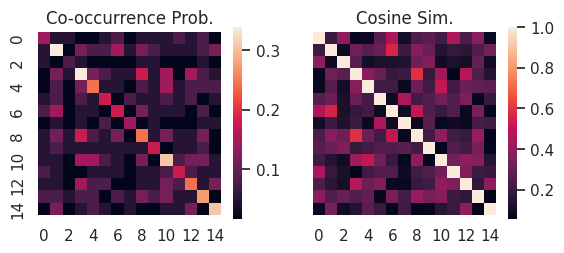

In [72]:
import affinis.associations as aff
coo = aff.coocur_prob(X)
cos = aff.ochiai(X)

f,ax = plt.subplots(ncols=2, figsize=(6.5,2.5), sharey=True)
sns.heatmap(coo,ax=ax[0], square=True)
ax[0].set_title('Co-occurrence Prob.')
sns.heatmap(cos,ax=ax[1], square=True)
ax[1].set_title('Cosine Sim.')
plt.savefig('../../docs/user-guide/img/cooc-prob.webp')

![Co-occurrence probability & Ochiai](img/cooc-prob.webp)

For more of this style of association measure provided by `affinis` see: 

- [Mutual Information][affinis.associations.mutual_information]
- [Yule's Y][affinis.associations.yule_y]
- [Yule's Q][affinis.associations.yule_q]
- [Odds Ratio][affinis.associations.odds_ratio]

## Using _all_ the Data

Rather than re-weighting the margnial probabilities, perhaps we can take advantage of the available bipartite structure of the full feature matrix. 
These methods require having the original data, since they re-weight individual observations (rows) using their activations. 

> For instance, if rows are _papers published_ and columns are _authors_, perhaps we want to equally share authorship of a many-author paper, but don't want the work of each author to be counted as equal to a single-author paper efforts.

See our documentation on [Hyperbolic Projections][affinis.associations.hyperbolic_project] and [Resource Allocation][affinis.associations.resource_project]

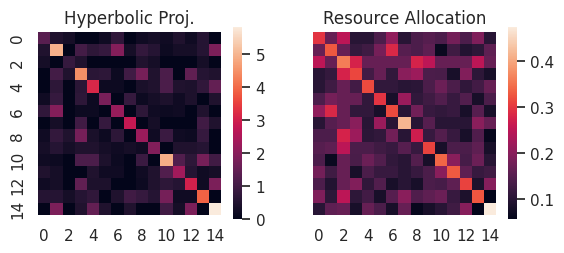

In [71]:
hyp = aff.hyperbolic_project(X)
rsc = aff.resource_project(X)

f,ax = plt.subplots(ncols=2, figsize=(6.5,2.5), sharey=True)
sns.heatmap(hyp,ax=ax[0], square=True)
sns.heatmap(rsc,ax=ax[1], square=True)
ax[0].set_title('Hyperbolic Proj.')
ax[1].set_title('Resource Allocation')
plt.savefig('../../docs/user-guide/img/bi-proj.webp')

![Hyperbolic-weighted and resource allocation](img/bi-proj.webp)

## Backboning & Structure Recovery

Going a bit further than pure association methods, for bipartite projection problems like these we are often trying to **backbone** our graph to only the relationships that convey meaningful structural relationships between features. 

!!! tip "Trimming Hairballs"
    Association measures are notorious for turning bipartite datasets into "hairballs"!
    **Backboning** is a term for the class of methods that try to "trim the hair", filtering out edges using principled (often statistical) techniques 


As examples, `affinis` provides implementations of the [High-Salience Skeleton][affinis.associations.high_salience_skeleton] backbone, as well as the [Doubly-Stochastic Filter][affinis.associations.doubly_stochastic_filter].

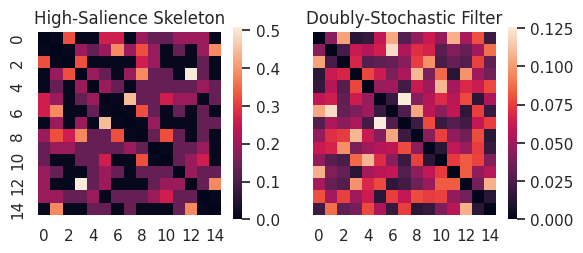

In [70]:
hss = aff.high_salience_skeleton(X)
dsf = aff.doubly_stochastic_filter(X)

f,ax = plt.subplots(ncols=2, figsize=(6.5,2.5), sharey=True)
sns.heatmap(hss,ax=ax[0], square=True)
sns.heatmap(dsf,ax=ax[1], square=True)
ax[0].set_title('High-Salience Skeleton')
ax[1].set_title('Doubly-Stochastic Filter')
plt.savefig(imgpath/'backbones.webp')

![backboning](img/backbones.webp)

Alternatively, we might try to discover an underlying **probabilistic graphical model** that could have generated our observations. While we do not provide any _covariance shrinkage_ methods that are popular for this (e.g. GLasso or Loopy Belief Propagation)[^1], we do provide an implementation of the [Chow-Liu][affinis.associations.chow_liu] tree method, as well as the newly proposed _Forest Pursuit_ estimate, both of which can recover probabilistic graphical models under appropriate assumptions. 

[^1]: Interested users might refer to more mature implementations of GLasso, such as the one found in [scikit-learn](https://scikit-learn.org/stable/modules/covariance.html#sparse-inverse-covariance) or [skggm](https://github.com/skggm/skggm), since these rely on complex optimization or sampling routines and are out-of-scope for `affinis`. 

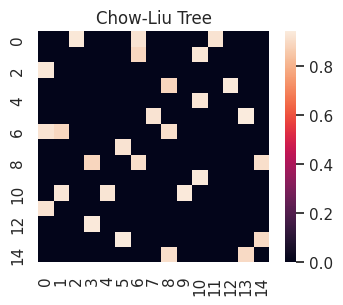

In [75]:
clt = aff.chow_liu(X)

sns.heatmap(clt, square=True)
plt.title('Chow-Liu Tree');
plt.savefig(imgpath/'chow-liu-tree.webp')

![Chow-Liu Tree](img/chow-liu-tree.webp)

### Forest Pursuit 

This recently proposed method by [Sexton (2025)](https://dissertation.rtbs.dev/content/part2/2-05-forest-pursuit.html) attempts to combine the local/additivity assumptions of the methods we've covered so far, while _also_ directly recovering an underlying network of _conditionally dependent_ pairs of nodes (the probabilistic graphical model). 

_Forest Pursuit_ replaces the inner product "counts" with an operator that treats observations as samples from a random spanning forest distribution (meaning that each observation is a result of a "spreading process").

This puts it somewhere between the previously discussed association measures (computationally) and the backboning/dependency-recovery methods (theoretically), while providing [exceptional scalability](https://dissertation.rtbs.dev/content/part2/2-05-forest-pursuit.html#results---runtime-performance), along with [accuracy and thresholding stability](https://dissertation.rtbs.dev/content/part2/2-05-forest-pursuit.html#results---scoring). 

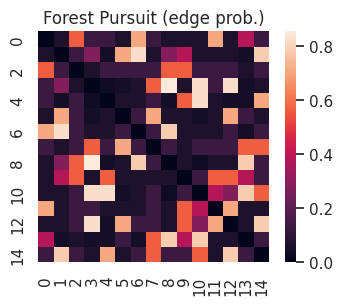

In [77]:
fps = aff.forest_pursuit(X)

sns.heatmap(fps, square=True)
plt.title('Forest Pursuit (edge prob.)')
plt.savefig(imgpath/'fp.webp')

![forest pursuit](img/fp.webp)

See our documentation on [Forest Pursuit][affinis.associations.forest_pursuit] for more. 

## Visualization


Often when comparing the ability of an association measure to recover _structure_ from a set of binary variable observations, it's not necessarily important to see the _values_ of the association, but instead _which relationships_ are strong _relative_ to the overall set. 

Colors (like we have used above) can be somewhat hard to parse, so another option is to represent association strength with **size**. 
This creates what we call a _Hinton diagram_. 
Size reflects normalized weight, while color can be used for the sign (positive vs negative). 



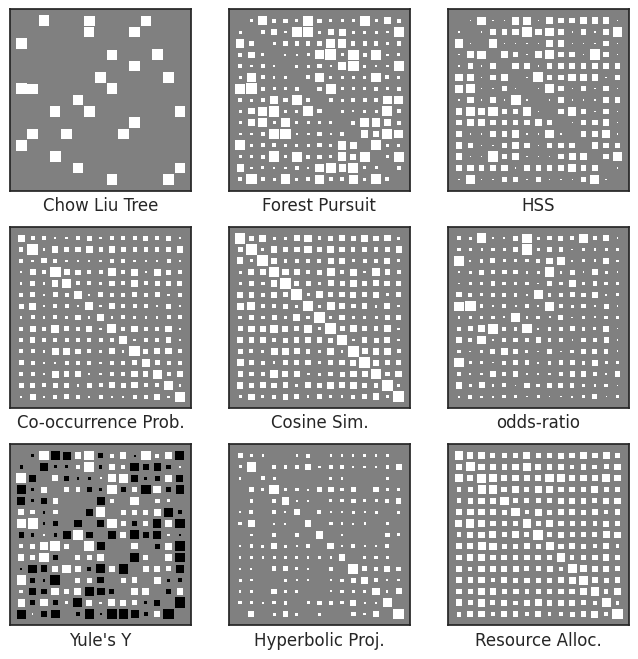

In [97]:
from affinis.plots import hinton

methods = {
    'Chow Liu Tree': clt,
    'Forest Pursuit': fps,  
    'HSS': hss,
    'Co-occurrence Prob.': coo,
    'Cosine Sim.': cos,
    'odds-ratio': aff.odds_ratio(X),
    'Yule\'s Y':aff.yule_y(X),
    'Hyperbolic Proj.': hyp,
    'Resource Alloc.':rsc,
}
f,axs = plt.subplots(nrows=3, ncols=3, figsize=(8,8))

for n, (lab, Aest) in enumerate(methods.items()): 
    ax = axs.flatten()[n]
    hinton(Aest, ax=ax)
    ax.set_xlabel(lab)

plt.savefig(imgpath/'assoc-overview.webp')

![overview of methods](img/assoc-overview.webp)